# Digital Twin: Project Development Practices

| No. | Name | Matric Number |
|:---:|------|:-------------:|
| 1 | FARISYA ADREA BINTI MOHAMMAD AMIN | 22011796 |
| 2 | WAN HARITH RIFQI BIN WAN MAZLI | 22011281 |
| 3 | RIZWI SHAAN MUHAMMED ALI | 24004260 |
| 4 | MUHAMMAD FARID | 24004254 |
| 5 | MOHAMMED SHAYAAN | 24004734 |

This notebook documents sprint planning and our execution as well as the version control practices, and the CI/CD regression pipeline for the Photodetector Digital Twin project.

| Member | Role |
|---|---|
| Rizwi Shaan | Lead Architect, Infrastructure, Data Streaming, & Deployment |
| Muhammad Farid | AI & Physics Modeling |
| Mohammed Shayaan | CI/CD Lead & Data Ingestion Support |
| Farisya Adrea | Project Specification, Planning, & Visualization |
| Wan Harith Rifqi | Project Specification, Planning, & Data Streaming Documentation |

---
## 2. Sprint 1 — Core System Development & Infrastructure

The GOAL was to build a completely functioning architecture, including the physics engine, API, data ingestion, containerization, and data visualization.

| Member | Deliverables |
|---|---|
| **Wan Harith Rifqi** | Co-authored the initial project specification and technical planning document, defining the digital twin problem statement, system objectives, sensor inputs, and target success metrics that guided the rest of the sprint. |
| **Farisya Adrea** | Co-authored the initial project specification and technical planning document alongside Wan Harith Rifqi. Also built the initial prototype for the AI algorithm/behavioral model — the early version of `AICommandPlanner`'s rule-based intent parser and telemetry-driven mode recommendation logic. |
| **Rizwi Shaan** | Developed the `ingestion` module (dual ZeroMQ PUB / MQTT publisher simulating photodetector telemetry), configured `docker-compose.yml` for multi-container orchestration across all five services, set up InfluxDB time-series aggregation, built the Grafana operational dashboards (bias voltage, SNR, photocurrent, dark current, temperature), integrated the Groq LLM API into `AICommandPlanner` for natural language command interpretation, designed the twin state data structures, and mapped the core FastAPI endpoints (`/health`, `/plan_command`). |
| **Muhammad Farid** | Developed the `PhotodetectorPhysicsEngine`, modeling temperature-dependent dark current drift and dynamic responsivity, and assisted in integrating the Groq LLM API into `AICommandPlanner`. |
| **Mohammed Shayaan** | Authored the `.github/workflows/ci.yml` CI/CD regression pipeline (automated build + pytest execution on every push/PR), established the repository skeleton and branch protection rules, and assisted Rizwi Shaan in developing the `ingestion` module (ZeroMQ/MQTT dual publisher). |


---
## 3. Sprint 2 — System Validation, Notebooks, and Documentation

The next step here was to lock down the codebase, execute system-wide testing, generate pass/fail evidence, and produce the assessed Jupyter notebooks.

| Member | Deliverables |
|---|---|
| **Wan Harith Rifqi** | Authored the **Data Streaming & Aggregation** notebook, covering multi-stream (ZMQ + MQTT) telemetry acquisition, aggregation, and conversion into digital twin state; documented the Flux queries used for InfluxDB downsampling and the Grafana dashboards. |
| **Farisya Adrea** | Put together the **Project Visualization** docs and built the Grafana dashboards.(bias voltage, latency, optical power, photocurrent, SNR, temperature, dark current trends) and the InfluxDB Data Explorer view of the raw `photodetector_telemetry` measurement and its fields. |
| **Rizwi Shaan** | Tested the local Docker Compose deployment and handled the final CI/CD pipeline checks before merging to main; authored the **Project Development Practices** notebook documenting sprint execution, version control history, and CI/CD pass/fail evidence. |
| **Muhammad Farid** | Authored the **AI/Behavioral Model** notebook, demonstrating LLM-based natural language intent interpretation, telemetry-driven autonomous mode switching, and physics-validated safety overrides. |
| **Mohammed Shayaan** | Authored the **Project Deployment** notebook, documenting the microservice interface contracts, containerization, deployment/scaling proof, persistence verification, and test suite results. |





---
## 4. Version Control Evidence
The following screenshots document the team's Git workflow across both sprints: feature-branch development, pull request review, and merges into the shared branch, spanning multiple modules of the system (AI planner, `docker-compose` configuration, project specification, ingestion, and MQTT/ZMQ integration).

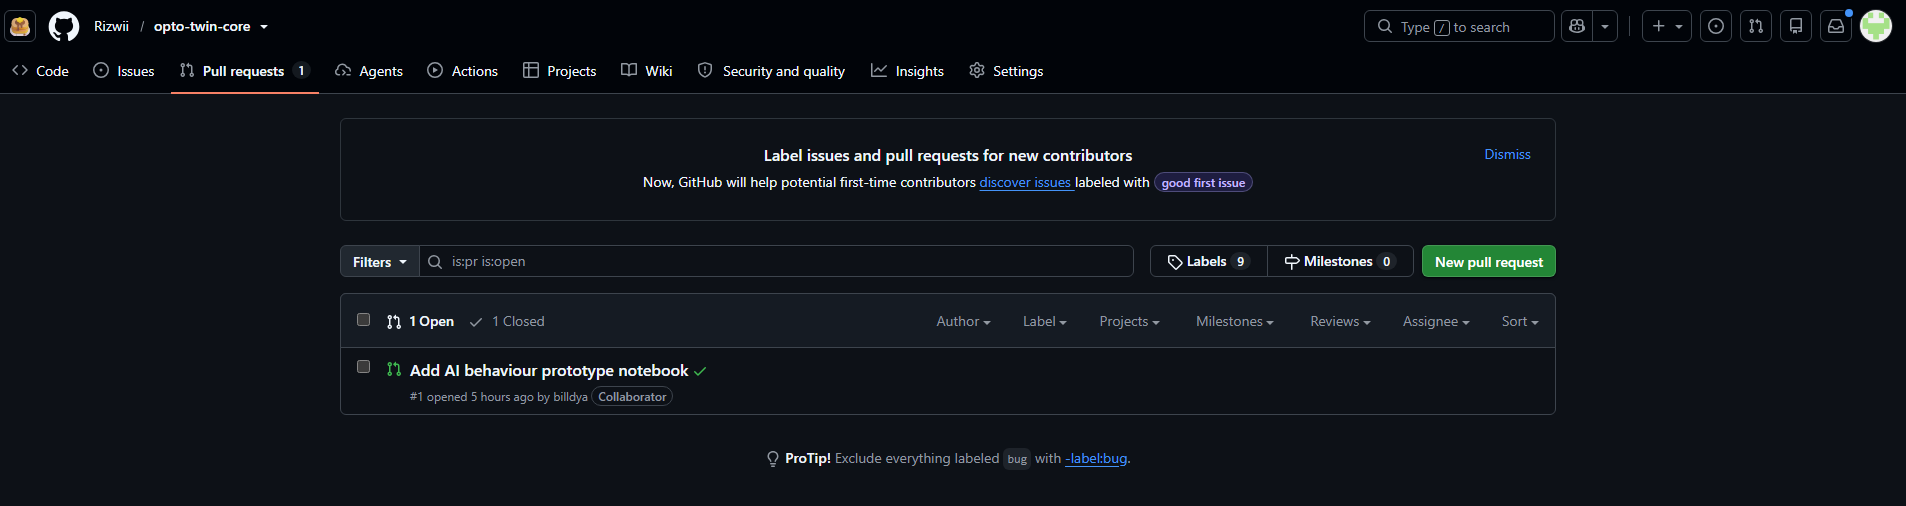
*figure 1 : The repository's Pull Requests tab shows collaborative review practice in action — for example, the "Add AI behaviour prototype notebook" PR, opened and tracked through GitHub's review workflow rather than committed directly to the shared branch.*




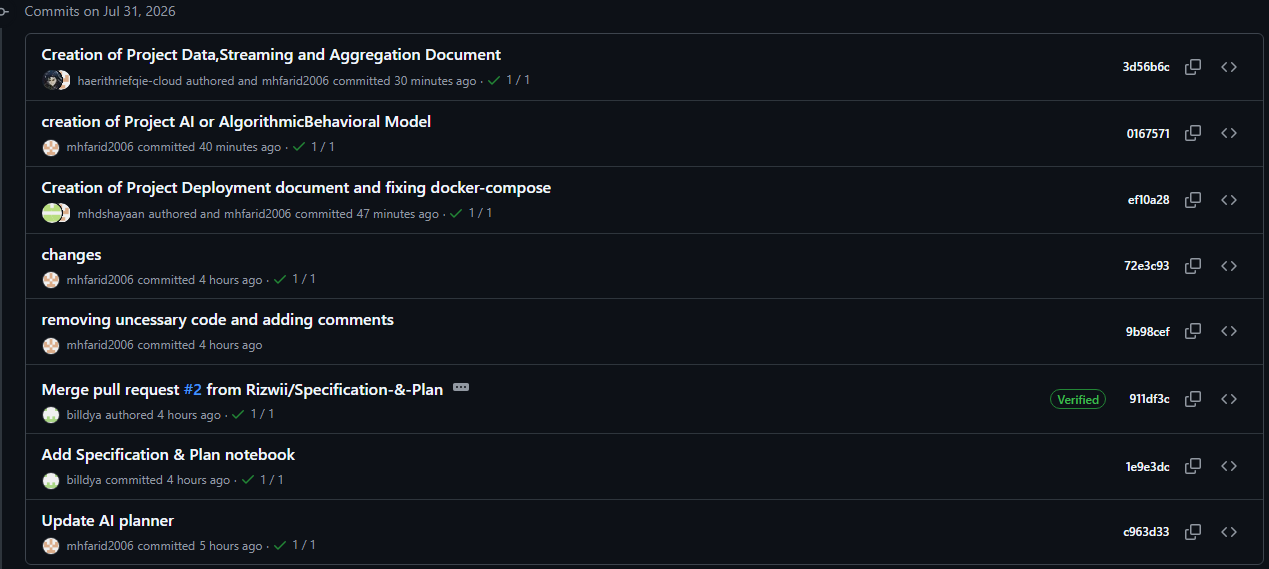
*figure 2:Commits from July 31, 2026 show contributions and merges spanning multiple modules:  work on the Data Streaming and Aggregation document, fixes to the deployment document and `docker-compose` configuration, and a verified merge of Pull Request #2 ("Specification & Plan") into the shared branch.*




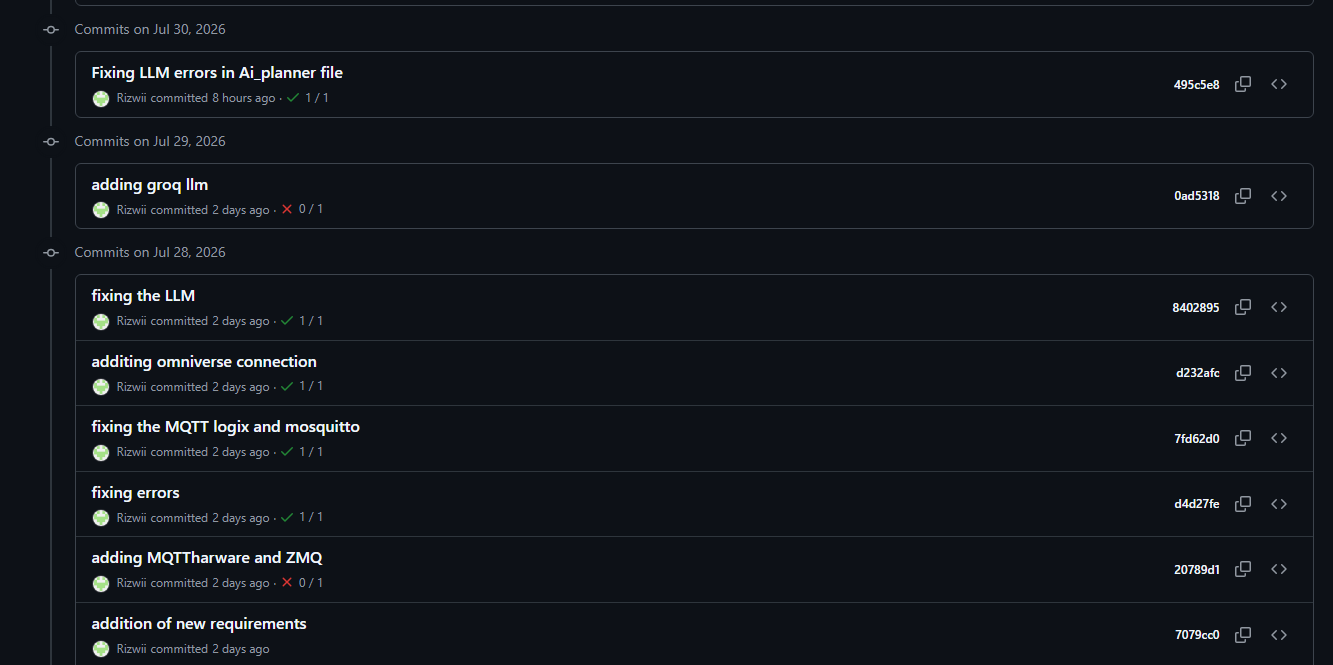
*figure 3 : Earlier commits show iterative work on the ingestion module — adding MQTT/ZMQ hardware integration, fixing MQTT logic and the Mosquitto broker configuration, integrating and debugging the Groq LLM connection in `ai_planner.py`, and refining system requirements over several commits.*



---
## 5. CI/CD Pipeline

### `.github/workflows/ci.yml`

The cell below reads and displays the actual CI/CD configuration file directly from the repository, confirming the pipeline definition is real and present on disk.

In [1]:
import os
os.chdir(r"C:\Users\rizwi\OneDrive\Desktop\opto-twin-core")

with open(".github/workflows/ci.yml") as f:
    print(f.read())

name: Opto-Twin CI/CD Regression Pipeline

on:
  push:
    branches: [ main, dev ]
  pull_request:
    branches: [ main ]

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout Repository
        uses: actions/checkout@v3

      - name: Set up Python 3.10
        uses: actions/setup-python@v4
        with:
          python-version: '3.10'

      - name: Install Dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt

      - name: Run PyTest Suite (Unit & Contract Tests)
        run: |
          pytest tests/ -v


### CI/CD Run Evidence
The screenshots below capture the pipeline actually executing in GitHub Actions, not just its static configuration — providing direct evidence that the automation described in `ci.yml` runs for real and produces genuine, reproducible results.

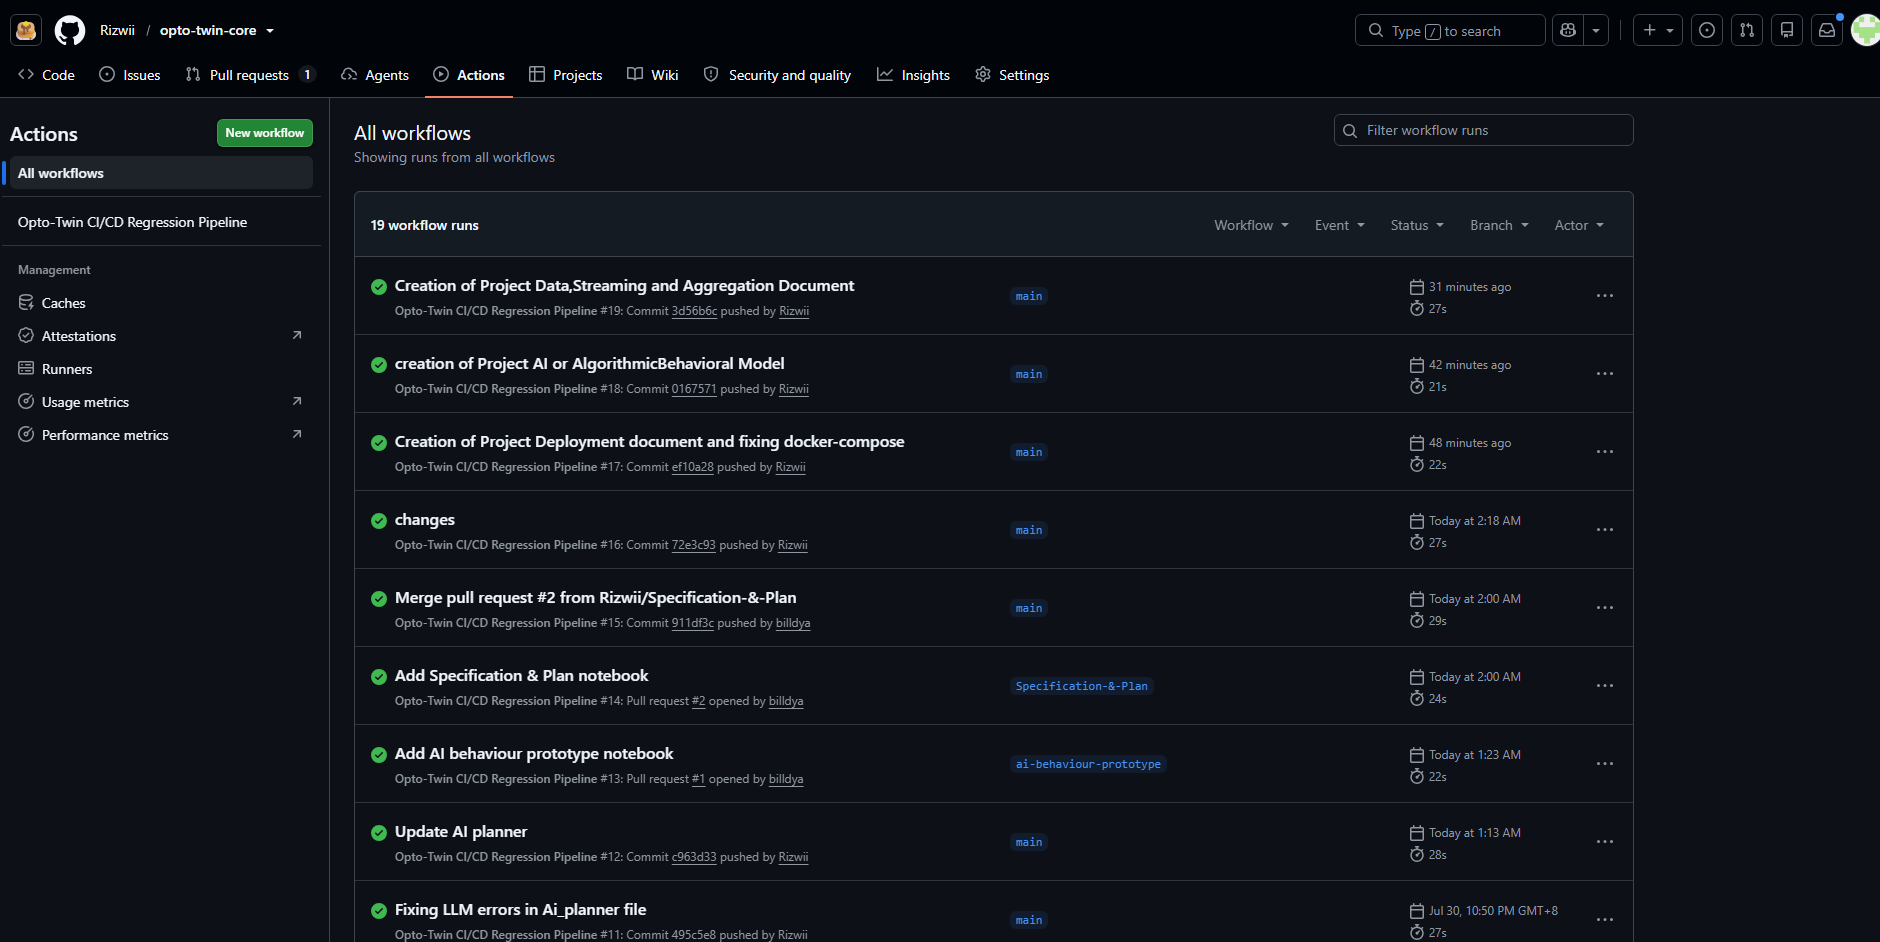
*figure 4 : The Actions history below shows the pipeline triggering automatically and consistently across the project's development, firing on nearly every commit and pull request — from early ingestion/MQTT fixes and LLM debugging, through to the final notebook and documentation commits. Each run independently rebuilds the environment and re-executes the full test suite, confirming the regression pipeline was active throughout both sprints rather than a one-off setup.*

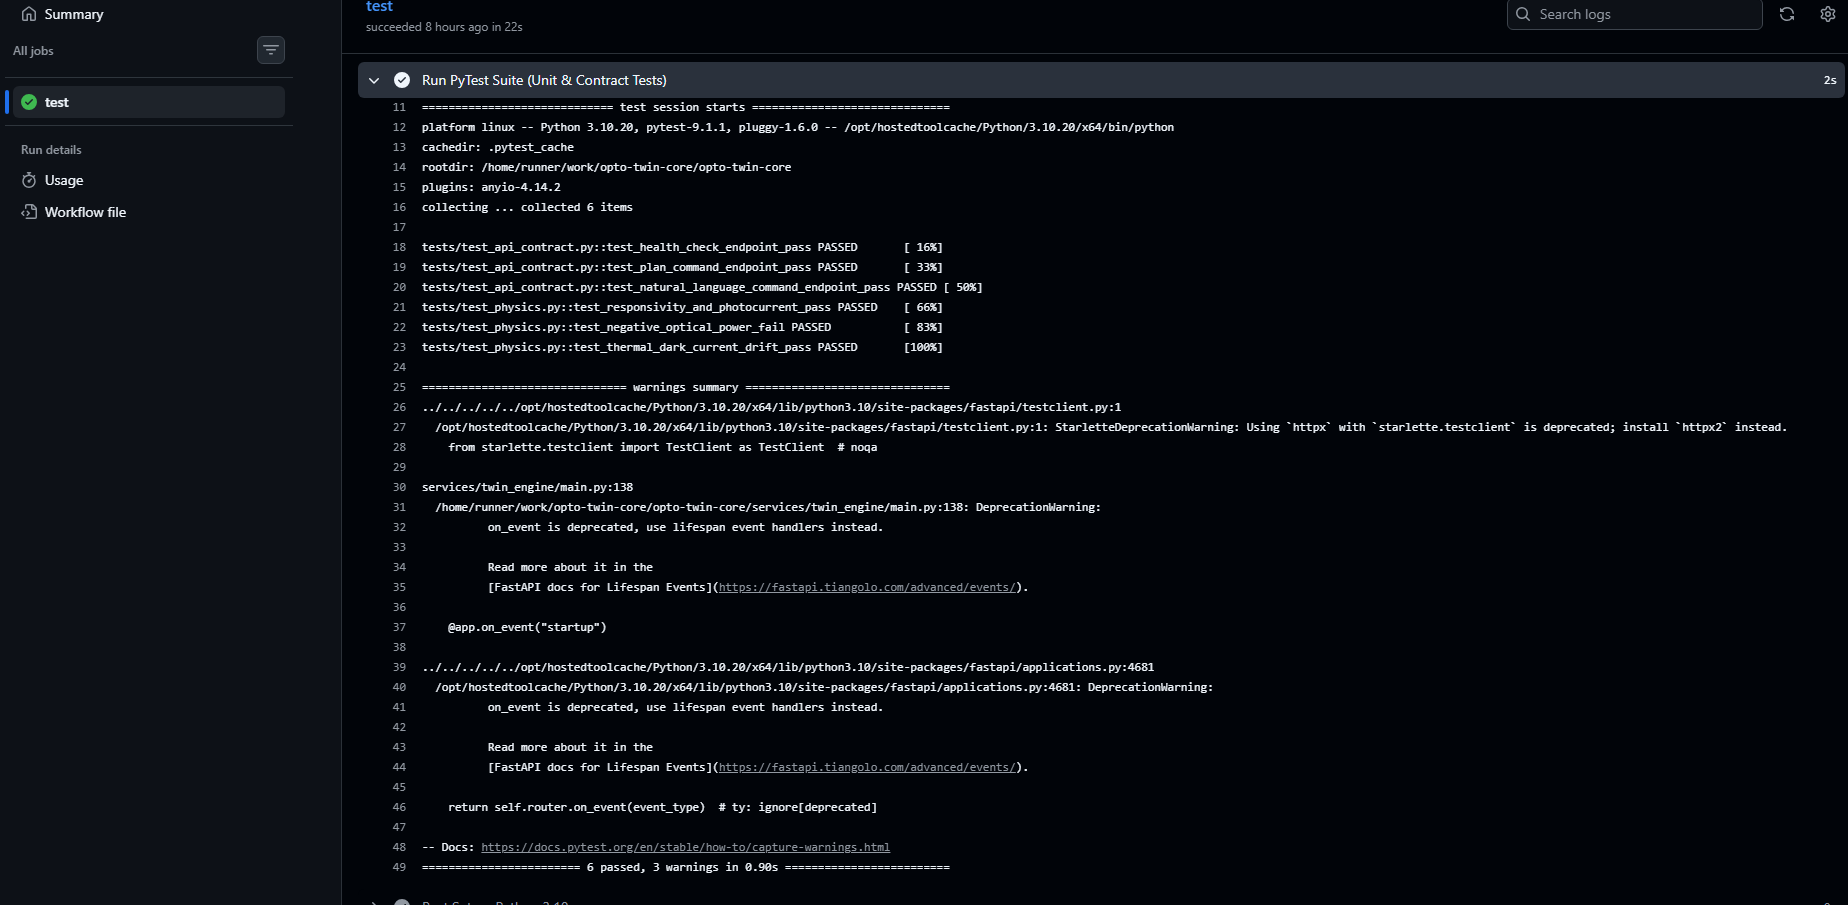
*figure 5 : A representative successful run of the "Run PyTest Suite (Unit & Contract Tests)" job, showing all 6 tests passing — covering both the physics engine (`test_physics.py`) and the FastAPI endpoint contracts (`test_api_contract.py`), including the deliberate negative-input exception test.*


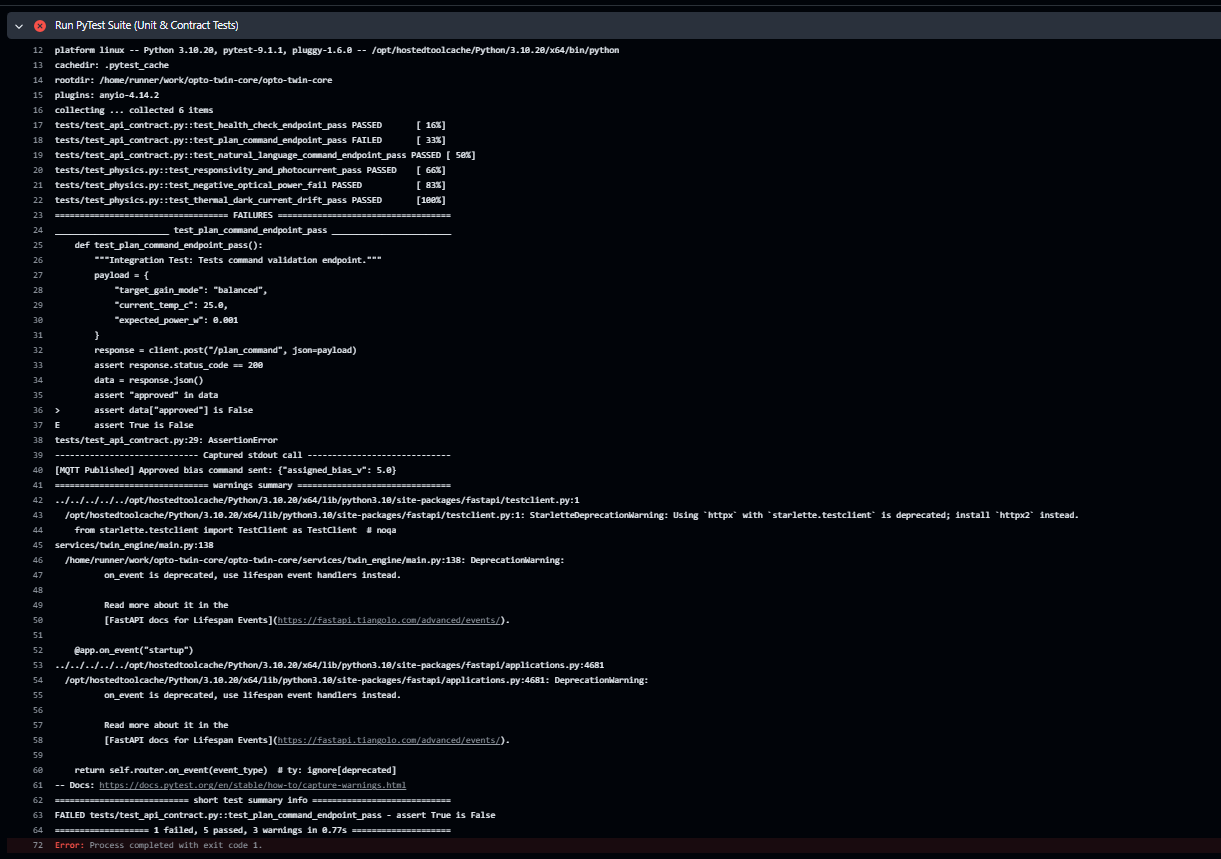
*figure 6 :To verify the pipeline genuinely detects regressions rather than always reporting success, a single assertion in `test_plan_command_endpoint_pass` was deliberately inverted (`assert data["approved"] is False`) and pushed. The pipeline correctly caught the failure, reporting "1 failed, 5 passed" with a full traceback pointing to the exact failing assertion, and returned a non-zero exit code. The change was reverted immediately afterward to restore the suite to a passing state.*

---
## Summary

This notebook has documented development practices used throughout the Photodetector Digital Twin project, consistent with the outcomes of this rubric section:

1. **Sprint Planning and Execution**: Work was broken down into two cycles or “sprints” that had very specific outcomes and deliverables based on each Sprint member. The Sprint 1 was dedicated to the foundation of functional architecture, encompassing the physics engine, ingestion pipeline, AI planner, containerization, and dashboards.The Sprint 1 was about the foundation of functional architecture such as the physics engine, ingestion pipeline, AI planner, containerization, and dashboards. Sprint 2 was dedicated to system-wide validation, to produce pass/fail evidence and to produce the documentation notebooks that were assessed.

2. **Version Control**: The team followed a branch-based workflow, creating and working on separate branches for individual features and merging through pull requests that were subject to review. Instead of a focus on a single part of the system, such as the AI planner, the ingestion service, `docker-compose` set up or project documentation, commit and PR history displays contributions across multiple modules.

3. **Testing**: A standalone test suite (both unit and integration tests, `test_physics.py` and `test_api_contract.py`) verifies that the physics engine behaves as expected as well as the live FastAPI endpoints, with specific tests for nominal behaviour, exception handling, and full API request/response cycles.

Every push and pull request will cause the environment to be rebuilt and the entire regression suite to be re-run, as part of a CI/CD GitHub Actions workflow (ci.yml). A true passing run and a intentional failing run is displayed—both in what the pipeline detects as a failure, indicating that it does not just pass because it is a failure.

These practices show a consistent and evidence-based development process, from planning to implementation, testing, and continuous integration, all the way through the entire life cycle of a project.